<a href="https://colab.research.google.com/github/mmbc560/GUIA2/blob/main/Ejemplo%20para%20la%20gu%C3%ADa%203_Gerencia%20por%20Procesos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# BASE DE DATOS GENERAL
# -----------------------------
df = pd.DataFrame({
    "caso_id": range(1, 21),
    "tipo": ["A","B","A","C","B","A","C","B","A","C","B","A","C","B","A","C","B","A","C","B"],
    "tiempo_recepcion": [5,6,4,7,5,6,8,5,4,7,6,5,8,6,5,7,6,5,8,6],
    "tiempo_validacion": [12,15,10,18,14,13,20,15,11,19,14,12,21,16,13,18,15,12,20,16],
    "tiempo_procesamiento": [25,28,22,35,30,27,40,29,23,38,31,26,41,30,24,36,32,27,39,31],
    "tiempo_control": [8,10,7,12,9,8,13,9,7,12,10,8,14,9,8,11,10,8,13,9],
    "tiempo_entrega": [6,7,5,9,7,6,10,7,5,9,8,6,10,7,6,9,8,6,10,7],
    "espera_validacion": [10,12,8,15,11,10,18,12,8,17,12,9,19,13,9,16,12,10,18,13],
    "espera_procesamiento": [14,16,12,20,15,14,22,16,12,21,17,13,23,17,14,20,16,14,22,17],
    "errores": [1,2,0,2,1,1,3,1,0,2,2,1,3,1,0,2,2,1,3,1],
    "reprocesos": [0,1,0,1,1,0,2,1,0,1,1,0,2,1,0,1,1,0,2,1],
    "costo_unitario": [120,130,118,145,132,125,150,131,119,147,134,123,152,133,121,146,136,124,151,134],
    "cumple_tiempo": [1,0,1,0,1,1,0,1,1,0,0,1,0,1,1,0,0,1,0,1]
})

etapas = ["tiempo_recepcion","tiempo_validacion","tiempo_procesamiento","tiempo_control","tiempo_entrega"]

df["lead_time_total"] = (
    df[etapas].sum(axis=1)
    + df["espera_validacion"]
    + df["espera_procesamiento"]
)

df["productividad"] = 100 / df["lead_time_total"]
df["tasa_error_pct"] = (df["errores"] / 5) * 100
df["tasa_reproceso_pct"] = (df["reprocesos"] / 5) * 100

print(df.head())
print("\nLead time promedio:", round(df["lead_time_total"].mean(), 2))
print("Costo promedio:", round(df["costo_unitario"].mean(), 2))

   caso_id tipo  tiempo_recepcion  tiempo_validacion  tiempo_procesamiento  \
0        1    A                 5                 12                    25   
1        2    B                 6                 15                    28   
2        3    A                 4                 10                    22   
3        4    C                 7                 18                    35   
4        5    B                 5                 14                    30   

   tiempo_control  tiempo_entrega  espera_validacion  espera_procesamiento  \
0               8               6                 10                    14   
1              10               7                 12                    16   
2               7               5                  8                    12   
3              12               9                 15                    20   
4               9               7                 11                    15   

   errores  reprocesos  costo_unitario  cumple_tiempo  lead_ti

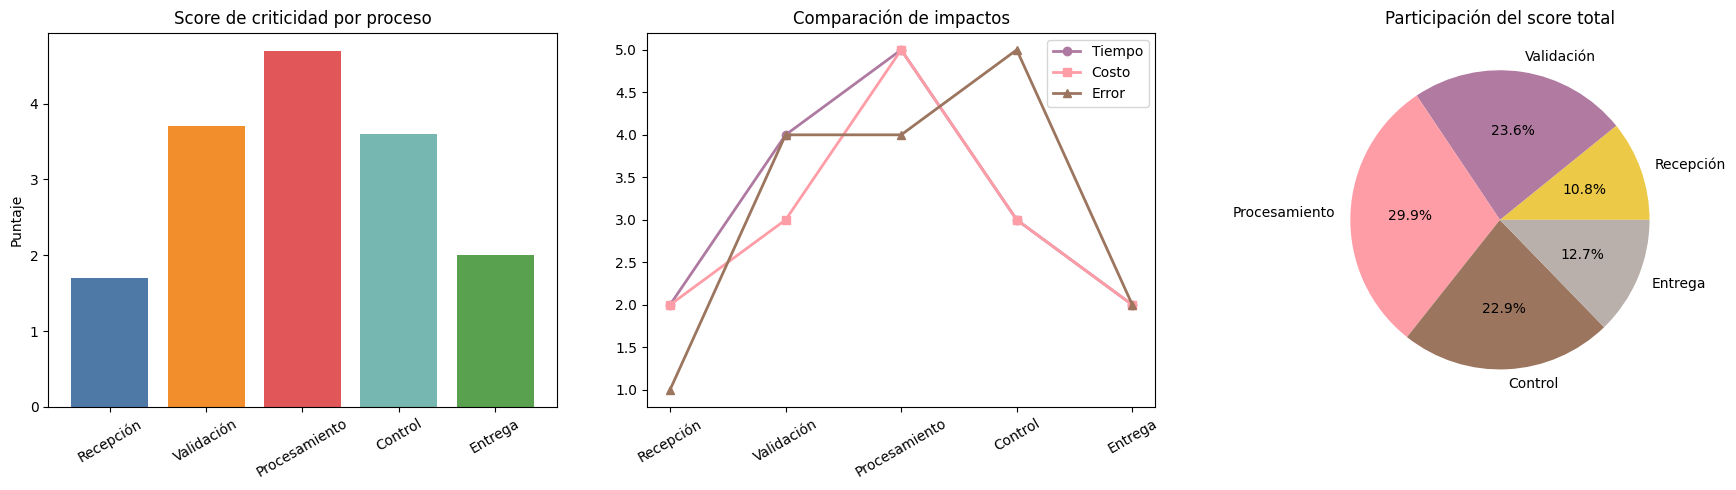

In [2]:
procesos = pd.DataFrame({
    "proceso": ["Recepción", "Validación", "Procesamiento", "Control", "Entrega"],
    "impacto_tiempo": [2, 4, 5, 3, 2],
    "impacto_costo": [2, 3, 5, 3, 2],
    "impacto_error": [1, 4, 4, 5, 2]
})

procesos["score"] = (
    0.4 * procesos["impacto_tiempo"] +
    0.3 * procesos["impacto_costo"] +
    0.3 * procesos["impacto_error"]
)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].bar(procesos["proceso"], procesos["score"],
          color=["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f"])
ax[0].set_title("Score de criticidad por proceso")
ax[0].set_ylabel("Puntaje")
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(procesos["proceso"], procesos["impacto_tiempo"], marker='o',
           color="#af7aa1", linewidth=2, label="Tiempo")
ax[1].plot(procesos["proceso"], procesos["impacto_costo"], marker='s',
           color="#ff9da7", linewidth=2, label="Costo")
ax[1].plot(procesos["proceso"], procesos["impacto_error"], marker='^',
           color="#9c755f", linewidth=2, label="Error")
ax[1].set_title("Comparación de impactos")
ax[1].legend()
ax[1].tick_params(axis='x', rotation=30)

ax[2].pie(procesos["score"], labels=procesos["proceso"], autopct='%1.1f%%',
          colors=["#edc948","#b07aa1","#ff9da7","#9c755f","#bab0ab"])
ax[2].set_title("Participación del score total")

plt.tight_layout()
plt.show()

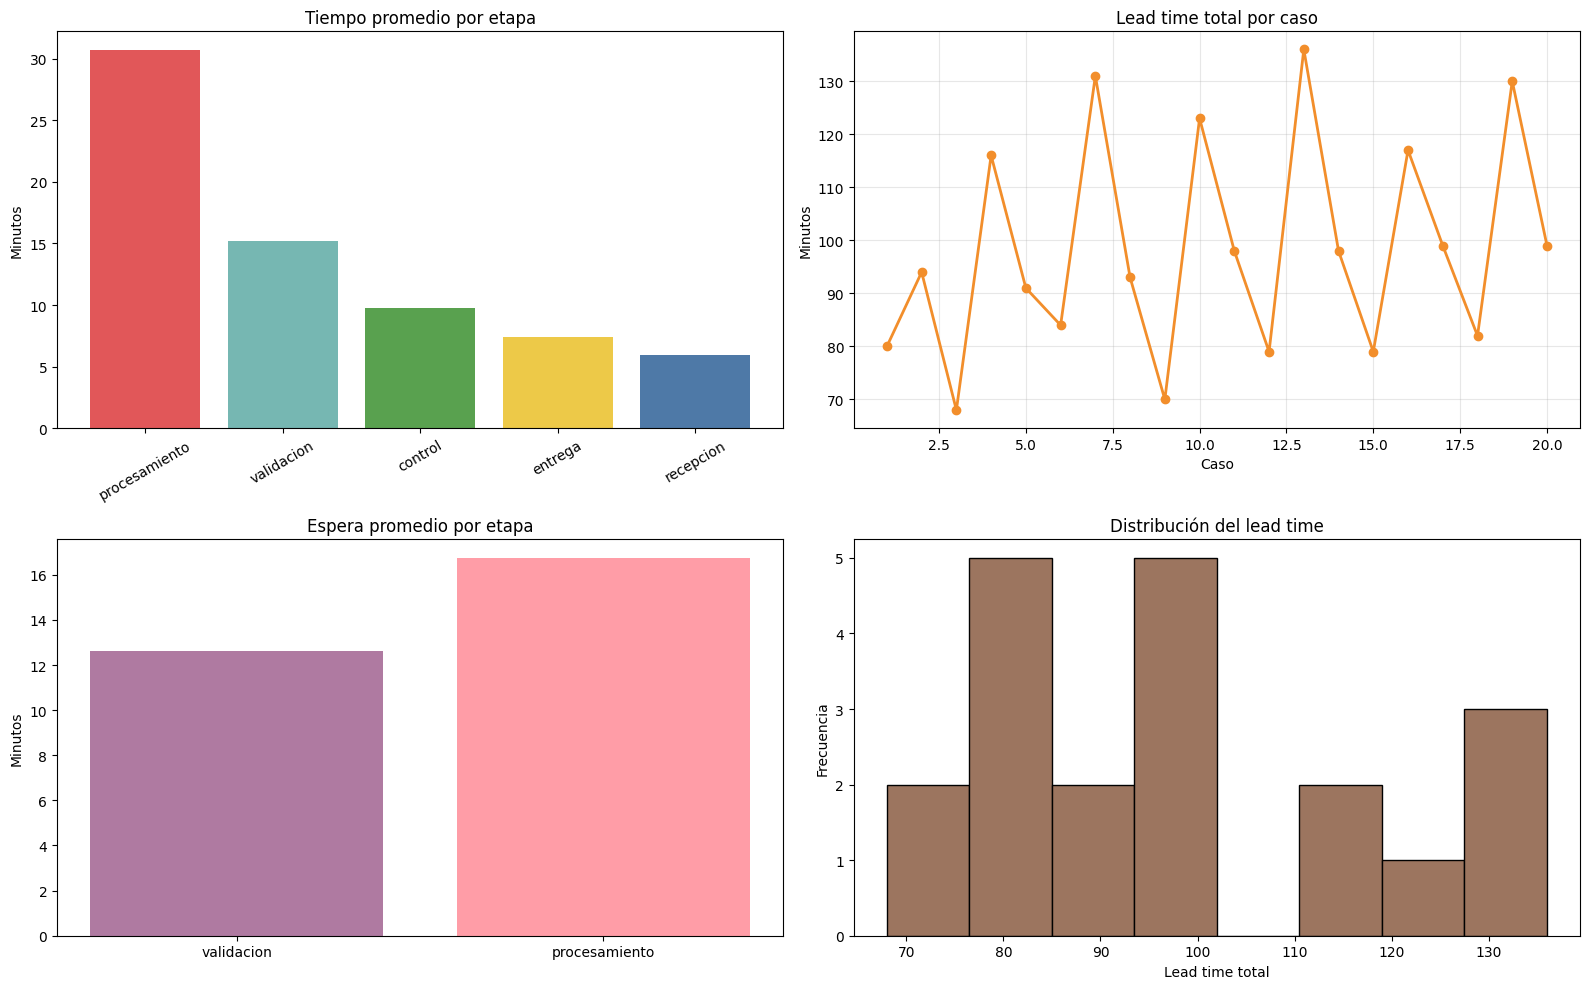

In [3]:
promedios_etapas = df[etapas].mean().sort_values(ascending=False)
esperas = df[["espera_validacion", "espera_procesamiento"]].mean()

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

ax[0, 0].bar(promedios_etapas.index.str.replace("tiempo_", ""),
             promedios_etapas.values,
             color=["#e15759","#76b7b2","#59a14f","#edc948","#4e79a7"])
ax[0, 0].set_title("Tiempo promedio por etapa")
ax[0, 0].set_ylabel("Minutos")
ax[0, 0].tick_params(axis='x', rotation=30)

ax[0, 1].plot(df["caso_id"], df["lead_time_total"], marker='o',
              color="#f28e2b", linewidth=2)
ax[0, 1].set_title("Lead time total por caso")
ax[0, 1].set_xlabel("Caso")
ax[0, 1].set_ylabel("Minutos")
ax[0, 1].grid(alpha=0.3)

ax[1, 0].bar(esperas.index.str.replace("espera_", ""), esperas.values,
             color=["#af7aa1","#ff9da7"])
ax[1, 0].set_title("Espera promedio por etapa")
ax[1, 0].set_ylabel("Minutos")

ax[1, 1].hist(df["lead_time_total"], bins=8, color="#9c755f", edgecolor="black")
ax[1, 1].set_title("Distribución del lead time")
ax[1, 1].set_xlabel("Lead time total")
ax[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

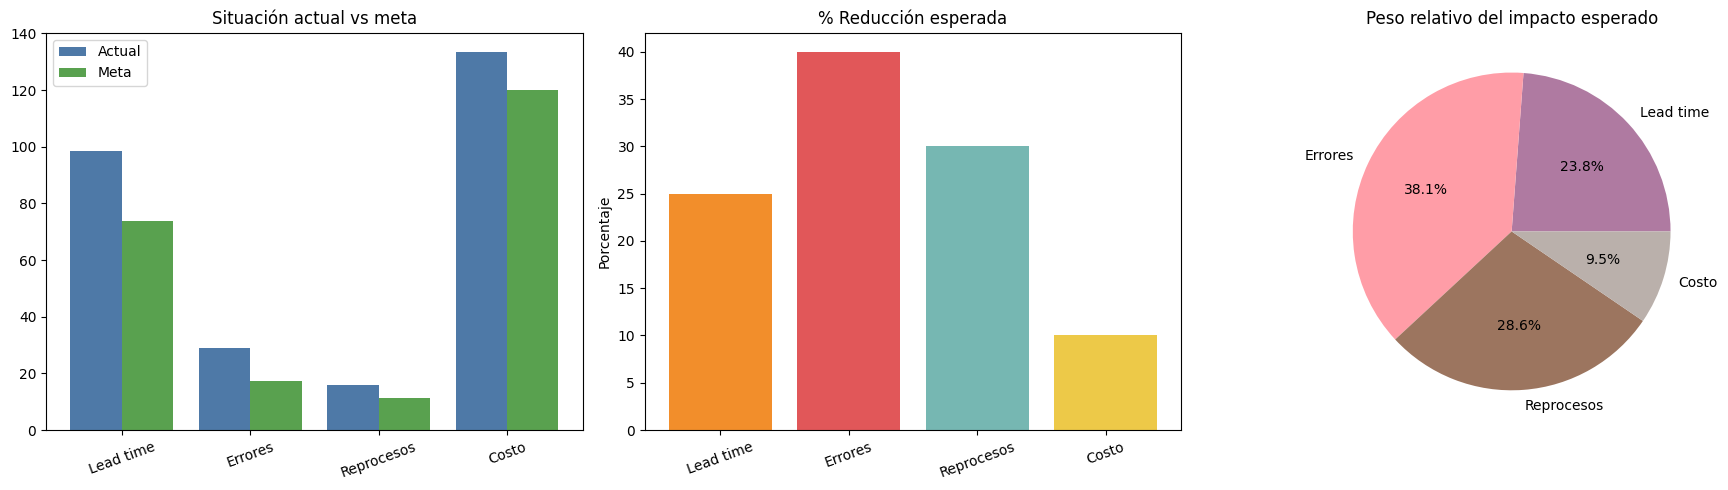

In [4]:
objetivos = pd.DataFrame({
    "indicador": ["Lead time", "Errores", "Reprocesos", "Costo"],
    "actual": [df["lead_time_total"].mean(), df["errores"].sum(), df["reprocesos"].sum(), df["costo_unitario"].mean()],
    "meta": [df["lead_time_total"].mean()*0.75, df["errores"].sum()*0.60, df["reprocesos"].sum()*0.70, df["costo_unitario"].mean()*0.90]
})

objetivos["reduccion_pct"] = ((objetivos["actual"] - objetivos["meta"]) / objetivos["actual"]) * 100

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(objetivos))
ax[0].bar(x - 0.2, objetivos["actual"], width=0.4, color="#4e79a7", label="Actual")
ax[0].bar(x + 0.2, objetivos["meta"], width=0.4, color="#59a14f", label="Meta")
ax[0].set_xticks(x)
ax[0].set_xticklabels(objetivos["indicador"], rotation=20)
ax[0].set_title("Situación actual vs meta")
ax[0].legend()

ax[1].bar(objetivos["indicador"], objetivos["reduccion_pct"],
          color=["#f28e2b","#e15759","#76b7b2","#edc948"])
ax[1].set_title("% Reducción esperada")
ax[1].set_ylabel("Porcentaje")
ax[1].tick_params(axis='x', rotation=20)

ax[2].pie(objetivos["reduccion_pct"], labels=objetivos["indicador"],
          autopct='%1.1f%%',
          colors=["#af7aa1","#ff9da7","#9c755f","#bab0ab"])
ax[2].set_title("Peso relativo del impacto esperado")

plt.tight_layout()
plt.show()

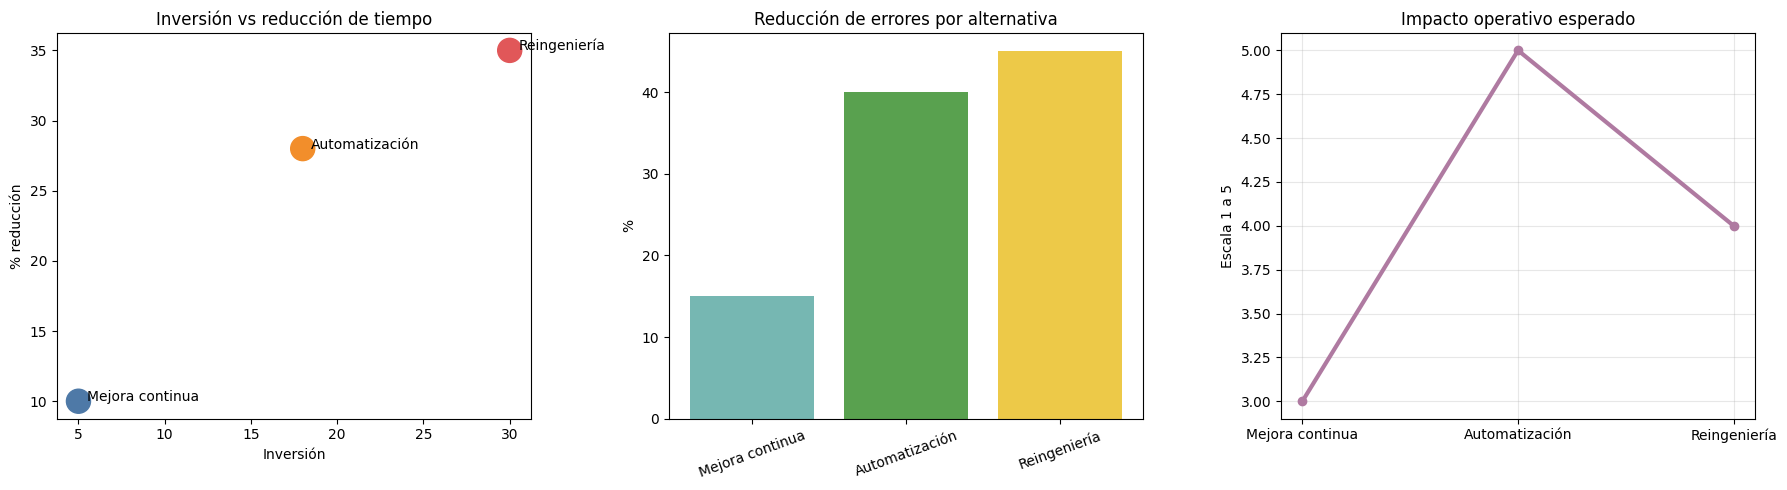

In [5]:
alternativas = pd.DataFrame({
    "alternativa": ["Mejora continua", "Automatización", "Reingeniería"],
    "inversion": [5, 18, 30],
    "reduccion_tiempo_pct": [10, 28, 35],
    "reduccion_error_pct": [15, 40, 45],
    "impacto_operativo": [3, 5, 4]
})

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].scatter(alternativas["inversion"], alternativas["reduccion_tiempo_pct"],
              s=300, c=["#4e79a7","#f28e2b","#e15759"])
for i, row in alternativas.iterrows():
    ax[0].text(row["inversion"]+0.5, row["reduccion_tiempo_pct"], row["alternativa"])
ax[0].set_title("Inversión vs reducción de tiempo")
ax[0].set_xlabel("Inversión")
ax[0].set_ylabel("% reducción")

ax[1].bar(alternativas["alternativa"], alternativas["reduccion_error_pct"],
          color=["#76b7b2","#59a14f","#edc948"])
ax[1].set_title("Reducción de errores por alternativa")
ax[1].set_ylabel("%")
ax[1].tick_params(axis='x', rotation=20)

ax[2].plot(alternativas["alternativa"], alternativas["impacto_operativo"],
           marker='o', linewidth=3, color="#af7aa1")
ax[2].set_title("Impacto operativo esperado")
ax[2].set_ylabel("Escala 1 a 5")
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

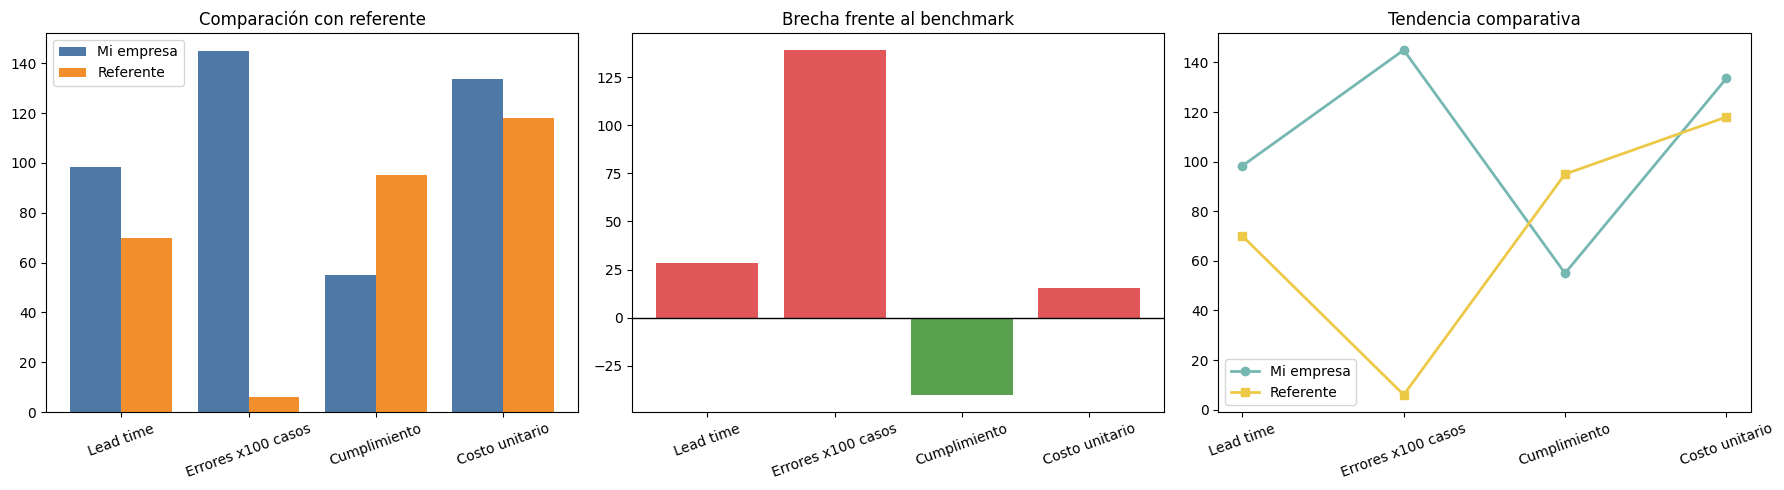

In [6]:
benchmark = pd.DataFrame({
    "indicador": ["Lead time", "Errores x100 casos", "Cumplimiento", "Costo unitario"],
    "mi_empresa": [df["lead_time_total"].mean(), df["errores"].sum()/len(df)*100, df["cumple_tiempo"].mean()*100, df["costo_unitario"].mean()],
    "referente": [70, 6, 95, 118]
})

benchmark["brecha"] = benchmark["mi_empresa"] - benchmark["referente"]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(benchmark))
ax[0].bar(x - 0.2, benchmark["mi_empresa"], width=0.4, color="#4e79a7", label="Mi empresa")
ax[0].bar(x + 0.2, benchmark["referente"], width=0.4, color="#f28e2b", label="Referente")
ax[0].set_xticks(x)
ax[0].set_xticklabels(benchmark["indicador"], rotation=20)
ax[0].set_title("Comparación con referente")
ax[0].legend()

ax[1].bar(benchmark["indicador"], benchmark["brecha"],
          color=["#e15759" if x > 0 else "#59a14f" for x in benchmark["brecha"]])
ax[1].set_title("Brecha frente al benchmark")
ax[1].axhline(0, color="black", linewidth=1)
ax[1].tick_params(axis='x', rotation=20)

ax[2].plot(benchmark["indicador"], benchmark["mi_empresa"], marker='o',
           color="#76b7b2", linewidth=2, label="Mi empresa")
ax[2].plot(benchmark["indicador"], benchmark["referente"], marker='s',
           color="#edc948", linewidth=2, label="Referente")
ax[2].set_title("Tendencia comparativa")
ax[2].legend()
ax[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

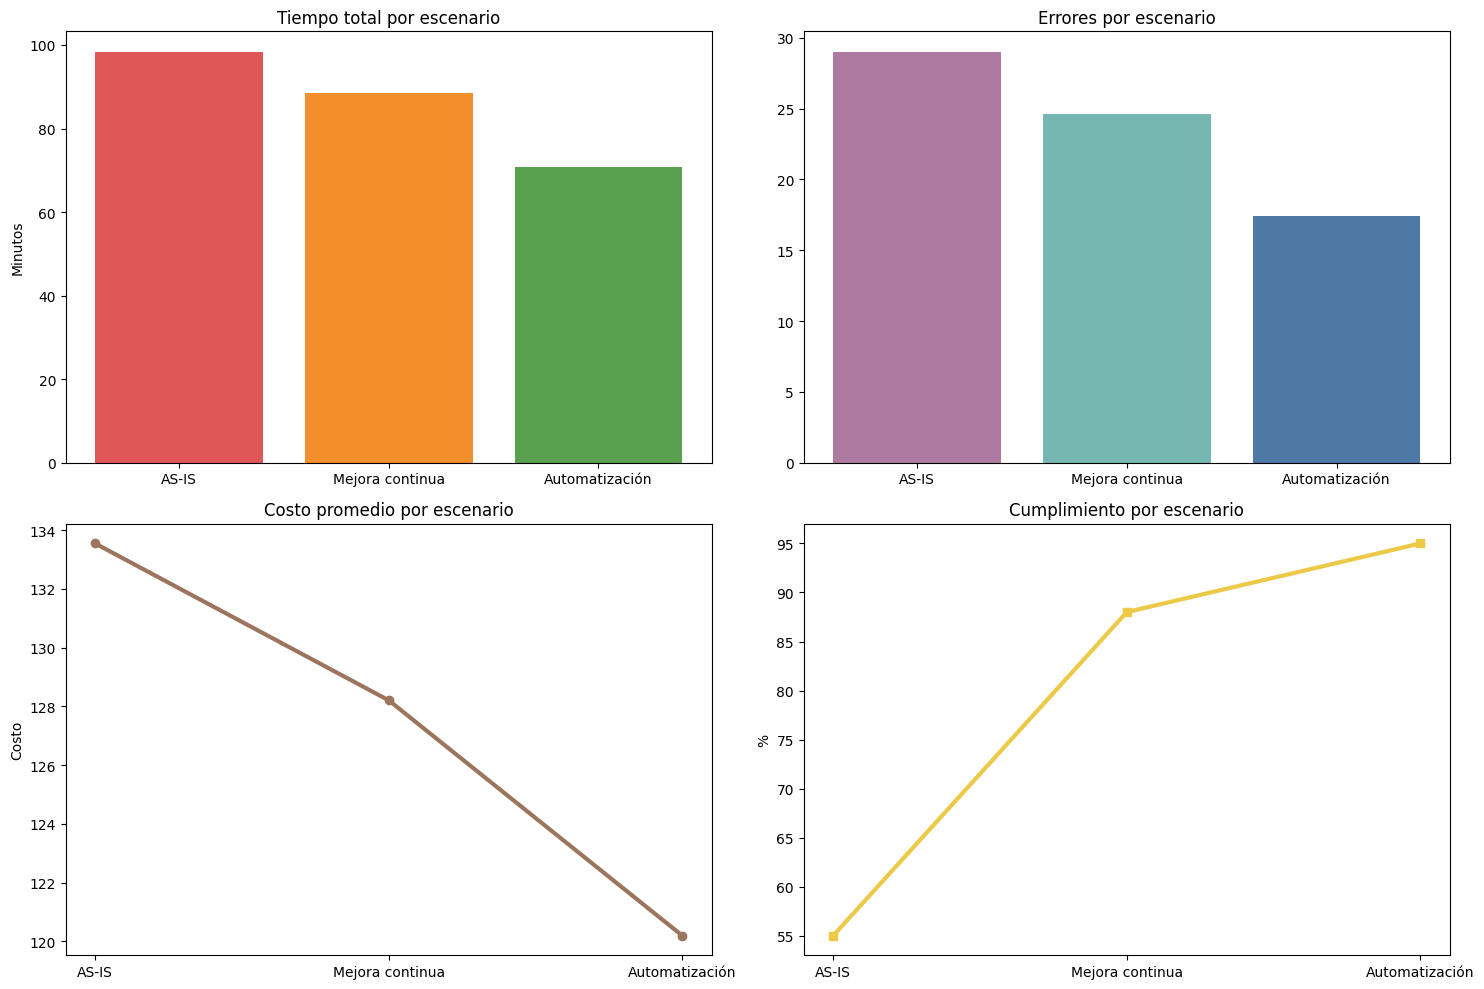

In [7]:
escenarios = pd.DataFrame({
    "escenario": ["AS-IS", "Mejora continua", "Automatización"],
    "tiempo_total": [df["lead_time_total"].mean(), df["lead_time_total"].mean()*0.90, df["lead_time_total"].mean()*0.72],
    "errores": [df["errores"].sum(), df["errores"].sum()*0.85, df["errores"].sum()*0.60],
    "costo": [df["costo_unitario"].mean(), df["costo_unitario"].mean()*0.96, df["costo_unitario"].mean()*0.90],
    "cumplimiento": [df["cumple_tiempo"].mean()*100, 88, 95]
})

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0].bar(escenarios["escenario"], escenarios["tiempo_total"],
             color=["#e15759","#f28e2b","#59a14f"])
ax[0, 0].set_title("Tiempo total por escenario")
ax[0, 0].set_ylabel("Minutos")

ax[0, 1].bar(escenarios["escenario"], escenarios["errores"],
             color=["#af7aa1","#76b7b2","#4e79a7"])
ax[0, 1].set_title("Errores por escenario")

ax[1, 0].plot(escenarios["escenario"], escenarios["costo"],
              marker='o', color="#9c755f", linewidth=3)
ax[1, 0].set_title("Costo promedio por escenario")
ax[1, 0].set_ylabel("Costo")

ax[1, 1].plot(escenarios["escenario"], escenarios["cumplimiento"],
              marker='s', color="#edc948", linewidth=3)
ax[1, 1].set_title("Cumplimiento por escenario")
ax[1, 1].set_ylabel("%")

plt.tight_layout()
plt.show()

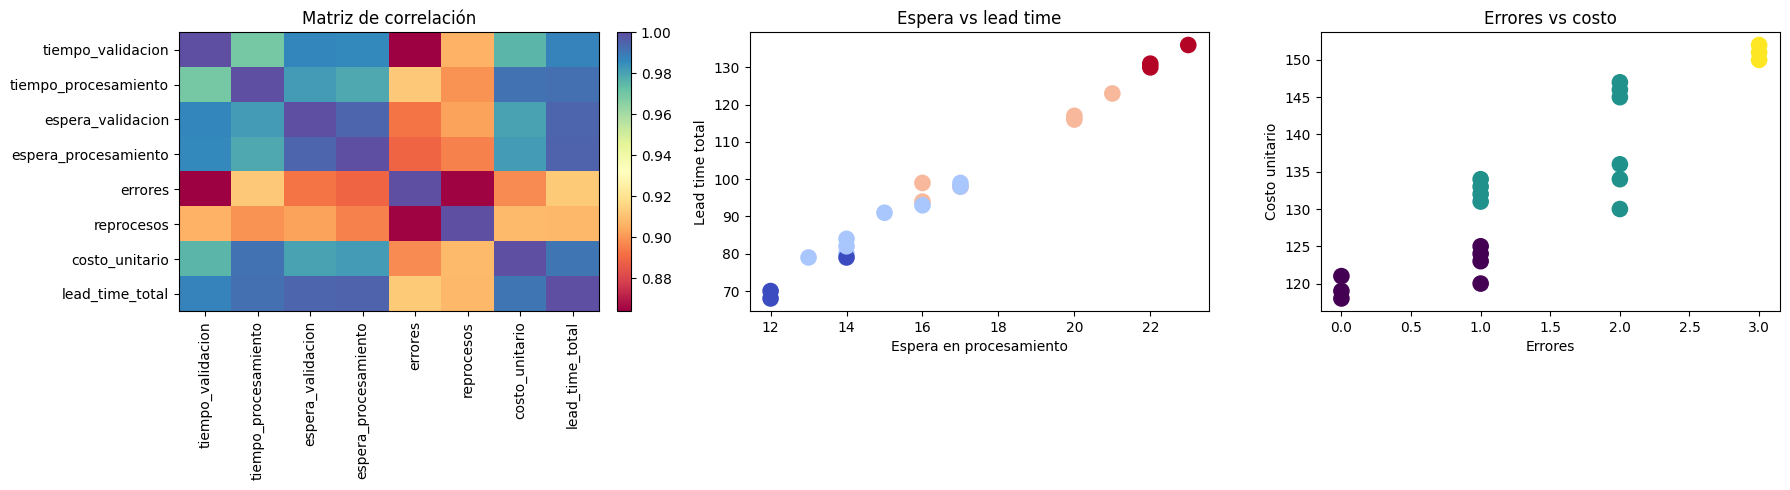

In [8]:
corr = df[[
    "tiempo_validacion","tiempo_procesamiento","espera_validacion",
    "espera_procesamiento","errores","reprocesos","costo_unitario","lead_time_total"
]].corr()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

im = ax[0].imshow(corr, cmap="Spectral", aspect="auto")
ax[0].set_xticks(range(len(corr.columns)))
ax[0].set_xticklabels(corr.columns, rotation=90)
ax[0].set_yticks(range(len(corr.columns)))
ax[0].set_yticklabels(corr.columns)
ax[0].set_title("Matriz de correlación")
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

ax[1].scatter(df["espera_procesamiento"], df["lead_time_total"],
              c=df["errores"], cmap="coolwarm", s=120)
ax[1].set_title("Espera vs lead time")
ax[1].set_xlabel("Espera en procesamiento")
ax[1].set_ylabel("Lead time total")

ax[2].scatter(df["errores"], df["costo_unitario"],
              c=df["reprocesos"], cmap="viridis", s=120)
ax[2].set_title("Errores vs costo")
ax[2].set_xlabel("Errores")
ax[2].set_ylabel("Costo unitario")

plt.tight_layout()
plt.show()

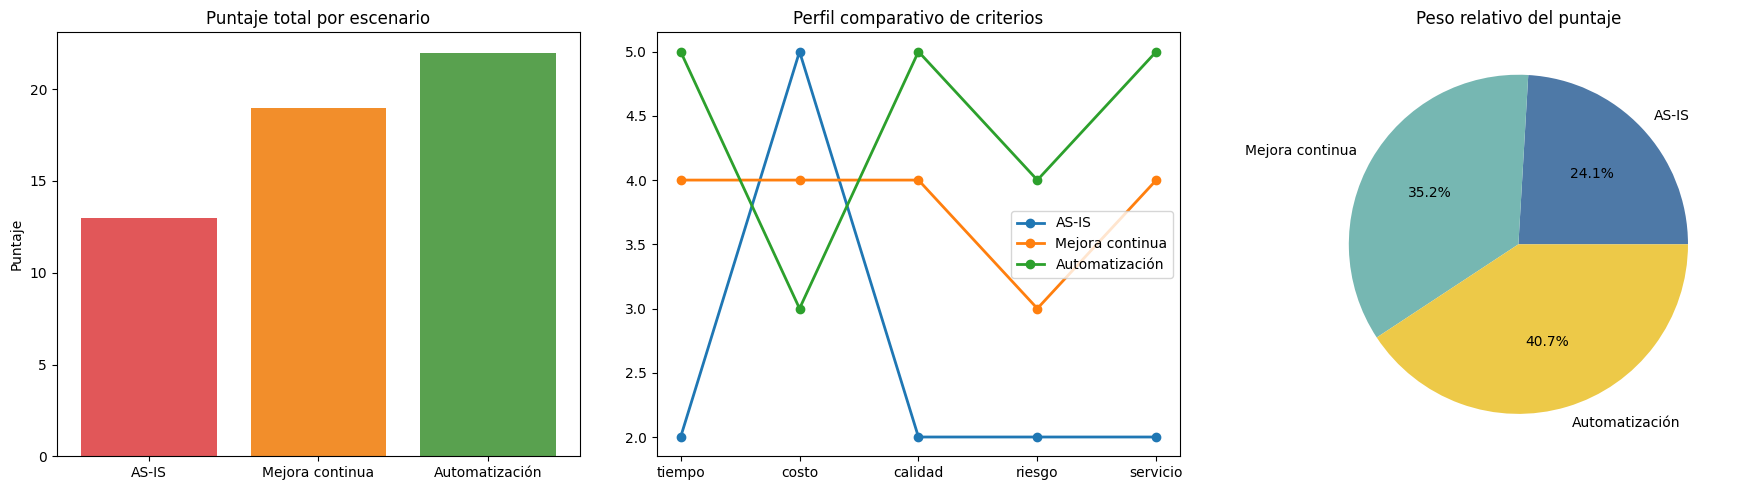

In [9]:
evaluacion = pd.DataFrame({
    "escenario": ["AS-IS", "Mejora continua", "Automatización"],
    "tiempo": [2, 4, 5],
    "costo": [5, 4, 3],
    "calidad": [2, 4, 5],
    "riesgo": [2, 3, 4],
    "servicio": [2, 4, 5]
})

evaluacion["total"] = evaluacion[["tiempo","costo","calidad","riesgo","servicio"]].sum(axis=1)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].bar(evaluacion["escenario"], evaluacion["total"],
          color=["#e15759","#f28e2b","#59a14f"])
ax[0].set_title("Puntaje total por escenario")
ax[0].set_ylabel("Puntaje")

for i, esc in enumerate(evaluacion["escenario"]):
    ax[1].plot(["tiempo","costo","calidad","riesgo","servicio"],
               evaluacion.loc[i, ["tiempo","costo","calidad","riesgo","servicio"]],
               marker='o', linewidth=2, label=esc)
ax[1].set_title("Perfil comparativo de criterios")
ax[1].legend()

participacion = evaluacion.set_index("escenario")["total"]
ax[2].pie(participacion, labels=participacion.index, autopct='%1.1f%%',
          colors=["#4e79a7","#76b7b2","#edc948"])
ax[2].set_title("Peso relativo del puntaje")

plt.tight_layout()
plt.show()

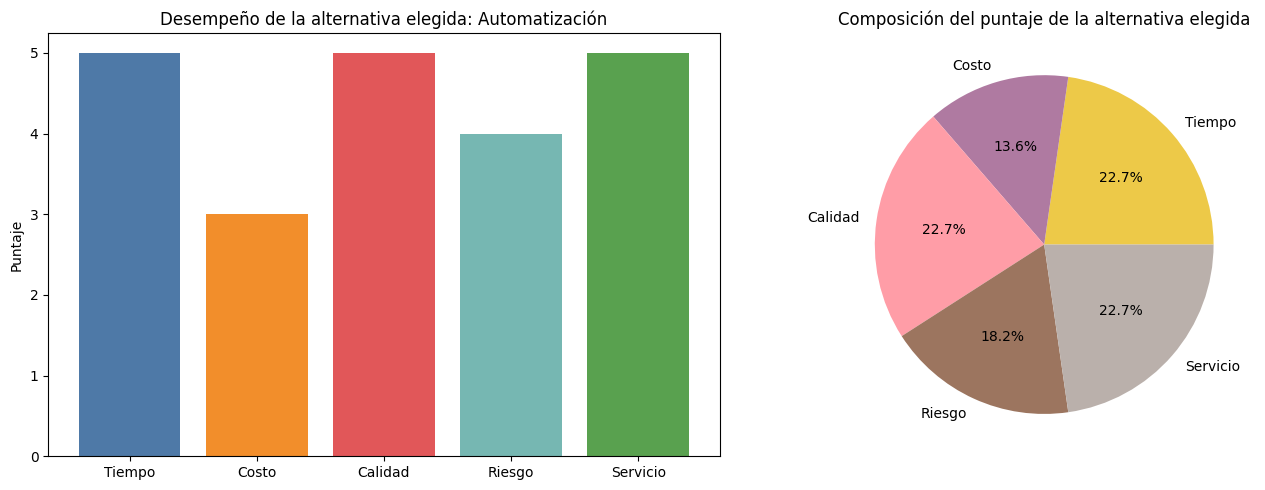

La mejor alternativa seleccionada es: Automatización


In [10]:
mejor_escenario = evaluacion.sort_values("total", ascending=False).iloc[0]["escenario"]

resumen_seleccion = pd.DataFrame({
    "criterio": ["Tiempo", "Costo", "Calidad", "Riesgo", "Servicio"],
    "puntaje_mejor": evaluacion.loc[evaluacion["escenario"] == mejor_escenario,
                                    ["tiempo","costo","calidad","riesgo","servicio"]].values.flatten()
})

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(resumen_seleccion["criterio"], resumen_seleccion["puntaje_mejor"],
          color=["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f"])
ax[0].set_title(f"Desempeño de la alternativa elegida: {mejor_escenario}")
ax[0].set_ylabel("Puntaje")

ax[1].pie(resumen_seleccion["puntaje_mejor"], labels=resumen_seleccion["criterio"],
          autopct='%1.1f%%',
          colors=["#edc948","#af7aa1","#ff9da7","#9c755f","#bab0ab"])
ax[1].set_title("Composición del puntaje de la alternativa elegida")

plt.tight_layout()
plt.show()

print("La mejor alternativa seleccionada es:", mejor_escenario)

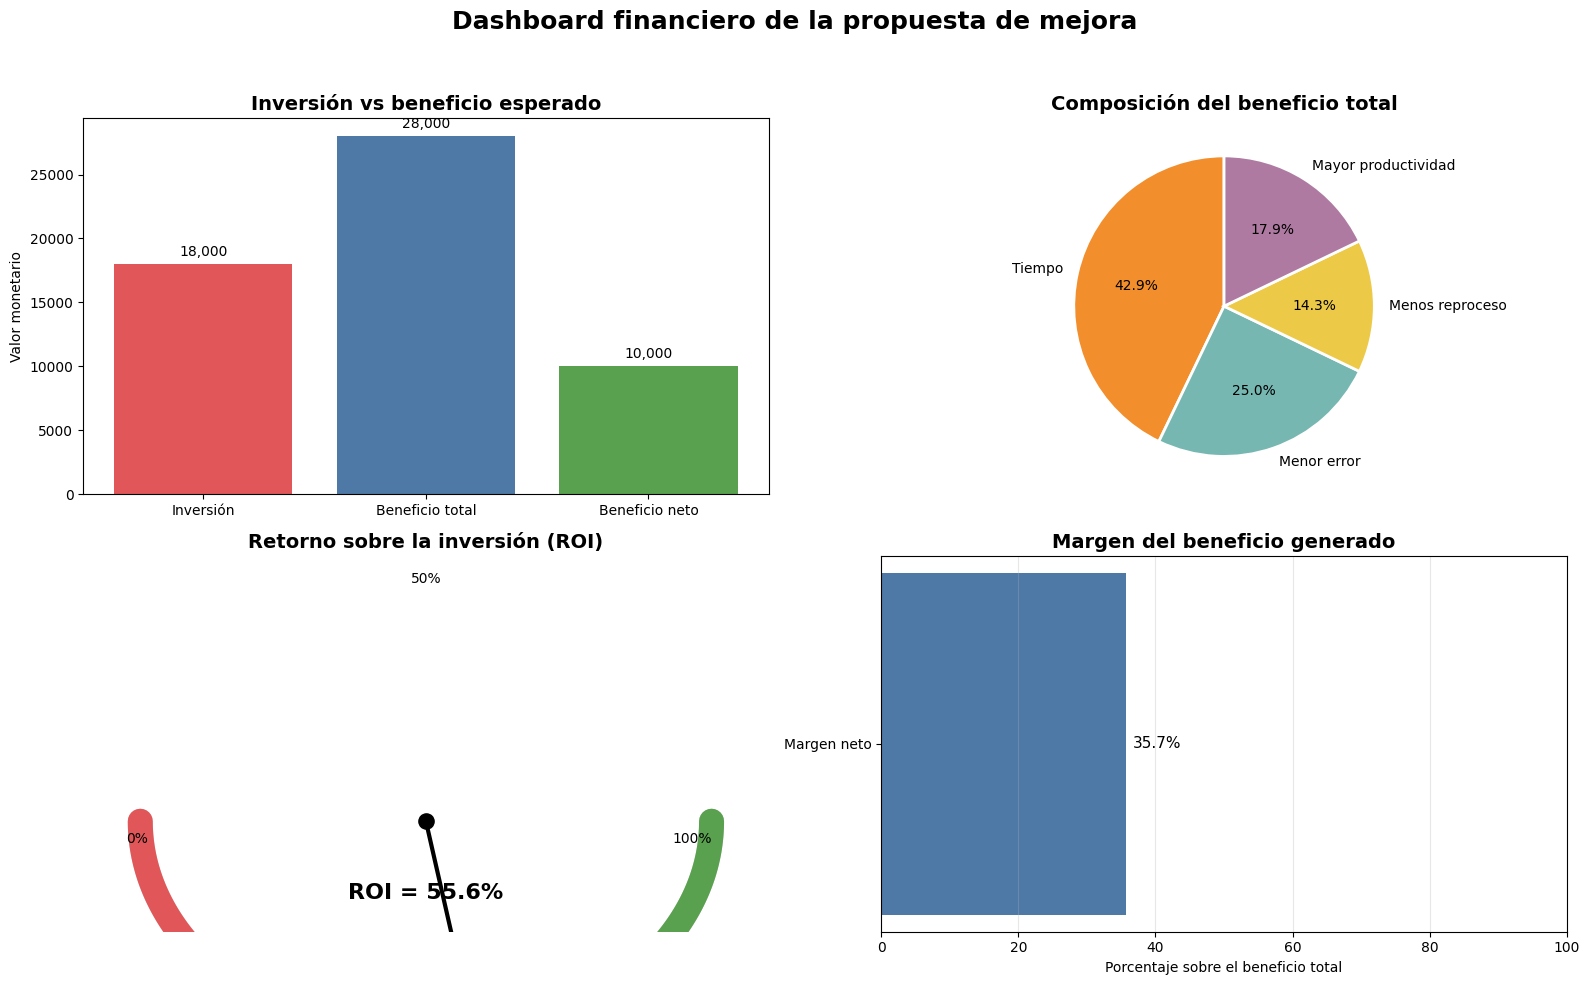

Inversión inicial: $18,000
Beneficio total: $28,000
Beneficio neto: $10,000
ROI: 55.56%
Margen del beneficio: 35.71%


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# DATOS FINANCIEROS AJUSTADOS
# -----------------------------
finanzas = pd.DataFrame({
    "concepto": [
        "Inversión inicial",
        "Ahorro por tiempo",
        "Ahorro por menor error",
        "Ahorro por menos reproceso",
        "Ahorro por mayor productividad"
    ],
    "valor": [18000, 12000, 7000, 4000, 5000]
})

# -----------------------------
# CÁLCULOS
# -----------------------------
inversion = finanzas.loc[finanzas["concepto"] == "Inversión inicial", "valor"].values[0]
ahorro_tiempo = finanzas.loc[finanzas["concepto"] == "Ahorro por tiempo", "valor"].values[0]
ahorro_error = finanzas.loc[finanzas["concepto"] == "Ahorro por menor error", "valor"].values[0]
ahorro_reproceso = finanzas.loc[finanzas["concepto"] == "Ahorro por menos reproceso", "valor"].values[0]
ahorro_productividad = finanzas.loc[finanzas["concepto"] == "Ahorro por mayor productividad", "valor"].values[0]

beneficio_total = ahorro_tiempo + ahorro_error + ahorro_reproceso + ahorro_productividad
beneficio_neto = beneficio_total - inversion
roi = (beneficio_neto / inversion) * 100
margen_beneficio = (beneficio_neto / beneficio_total) * 100

# Resúmenes
resumen = pd.DataFrame({
    "indicador": ["Inversión", "Beneficio total", "Beneficio neto"],
    "valor": [inversion, beneficio_total, beneficio_neto]
})

ahorros = pd.DataFrame({
    "fuente": ["Tiempo", "Menor error", "Menos reproceso", "Mayor productividad"],
    "valor": [ahorro_tiempo, ahorro_error, ahorro_reproceso, ahorro_productividad]
})

# -----------------------------
# DASHBOARD FINANCIERO
# -----------------------------
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

# 1. Inversión vs beneficios
colors1 = ["#E15759", "#4E79A7", "#59A14F"]
bars = ax[0, 0].bar(resumen["indicador"], resumen["valor"], color=colors1)
ax[0, 0].set_title("Inversión vs beneficio esperado", fontsize=14, weight="bold")
ax[0, 0].set_ylabel("Valor monetario")
for bar in bars:
    h = bar.get_height()
    ax[0, 0].text(bar.get_x() + bar.get_width()/2, h + 400, f"{h:,.0f}",
                  ha="center", va="bottom", fontsize=10)

# 2. Composición del beneficio total
colors2 = ["#F28E2B", "#76B7B2", "#EDC948", "#AF7AA1"]
ax[0, 1].pie(
    ahorros["valor"],
    labels=ahorros["fuente"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors2,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax[0, 1].set_title("Composición del beneficio total", fontsize=14, weight="bold")

# 3. ROI más interesante: velocímetro semicircular
ax[1, 0].set_title("Retorno sobre la inversión (ROI)", fontsize=14, weight="bold")
ax[1, 0].axis("off")

# parámetros del velocímetro
max_roi = 100
valor = min(max(roi, 0), max_roi)

# semicírculo base
theta = np.linspace(np.pi, 2*np.pi, 200)
x = np.cos(theta)
y = np.sin(theta)
ax[1, 0].plot(x, y, color="lightgray", linewidth=18, solid_capstyle='round')

# zonas de color
zonas = [
    (0, 30, "#E15759"),
    (30, 60, "#EDC948"),
    (60, 100, "#59A14F")
]

for inicio, fin, color in zonas:
    t = np.linspace(np.pi + (inicio/max_roi)*np.pi, np.pi + (fin/max_roi)*np.pi, 100)
    ax[1, 0].plot(np.cos(t), np.sin(t), color=color, linewidth=18, solid_capstyle='round')

# aguja
angulo = np.pi + (valor/max_roi)*np.pi
ax[1, 0].plot([0, 0.75*np.cos(angulo)], [0, 0.75*np.sin(angulo)], color="black", linewidth=3)
ax[1, 0].scatter(0, 0, s=120, color="black")

# etiquetas
ax[1, 0].text(-1.05, -0.1, "0%", fontsize=10)
ax[1, 0].text(0, 1.08, "50%", fontsize=10, ha="center")
ax[1, 0].text(1.0, -0.1, "100%", fontsize=10, ha="right")
ax[1, 0].text(0, -0.35, f"ROI = {roi:.1f}%", ha="center", fontsize=16, weight="bold")
ax[1, 0].set_xlim(-1.2, 1.2)
ax[1, 0].set_ylim(-0.5, 1.2)

# 4. Margen del beneficio neto sobre beneficio total
ax[1, 1].barh(["Margen neto"], [margen_beneficio], color="#4E79A7", height=0.5)
ax[1, 1].set_xlim(0, 100)
ax[1, 1].set_title("Margen del beneficio generado", fontsize=14, weight="bold")
ax[1, 1].set_xlabel("Porcentaje sobre el beneficio total")
ax[1, 1].text(margen_beneficio + 1, 0, f"{margen_beneficio:.1f}%", va="center", fontsize=11)
ax[1, 1].grid(axis="x", alpha=0.3)

plt.suptitle("Dashboard financiero de la propuesta de mejora", fontsize=18, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# -----------------------------
# RESULTADOS
# -----------------------------
print(f"Inversión inicial: ${inversion:,.0f}")
print(f"Beneficio total: ${beneficio_total:,.0f}")
print(f"Beneficio neto: ${beneficio_neto:,.0f}")
print(f"ROI: {roi:.2f}%")
print(f"Margen del beneficio: {margen_beneficio:.2f}%")

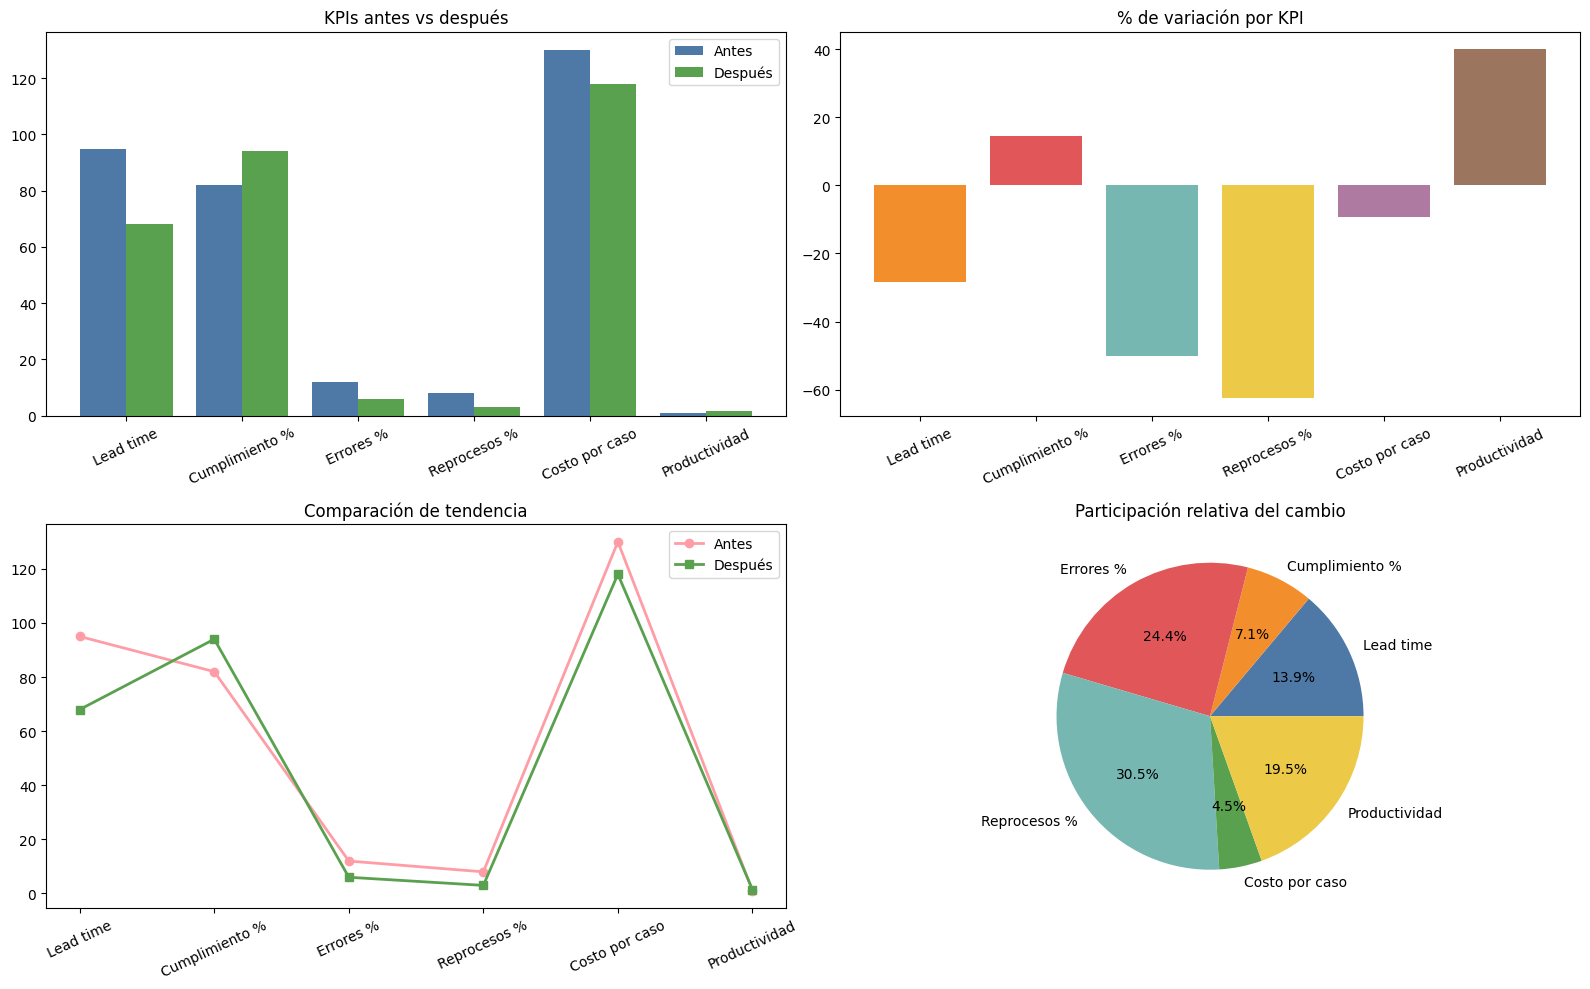

In [16]:
kpi = pd.DataFrame({
    "KPI": ["Lead time", "Cumplimiento %", "Errores %", "Reprocesos %", "Costo por caso", "Productividad"],
    "Antes": [95, 82, 12, 8, 130, 1.05],
    "Despues": [68, 94, 6, 3, 118, 1.47]
})

kpi["mejora_pct"] = ((kpi["Despues"] - kpi["Antes"]) / kpi["Antes"]) * 100

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

x = np.arange(len(kpi))
ax[0, 0].bar(x - 0.2, kpi["Antes"], width=0.4, color="#4e79a7", label="Antes")
ax[0, 0].bar(x + 0.2, kpi["Despues"], width=0.4, color="#59a14f", label="Después")
ax[0, 0].set_xticks(x)
ax[0, 0].set_xticklabels(kpi["KPI"], rotation=25)
ax[0, 0].set_title("KPIs antes vs después")
ax[0, 0].legend()

ax[0, 1].bar(kpi["KPI"], kpi["mejora_pct"],
             color=["#f28e2b","#e15759","#76b7b2","#edc948","#af7aa1","#9c755f"])
ax[0, 1].set_title("% de variación por KPI")
ax[0, 1].tick_params(axis='x', rotation=25)

ax[1, 0].plot(kpi["KPI"], kpi["Antes"], marker='o', linewidth=2, color="#ff9da7", label="Antes")
ax[1, 0].plot(kpi["KPI"], kpi["Despues"], marker='s', linewidth=2, color="#59a14f", label="Después")
ax[1, 0].set_title("Comparación de tendencia")
ax[1, 0].legend()
ax[1, 0].tick_params(axis='x', rotation=25)

ax[1, 1].pie(abs(kpi["mejora_pct"]), labels=kpi["KPI"], autopct='%1.1f%%',
             colors=["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f","#edc948"])
ax[1, 1].set_title("Participación relativa del cambio")

plt.tight_layout()
plt.show()

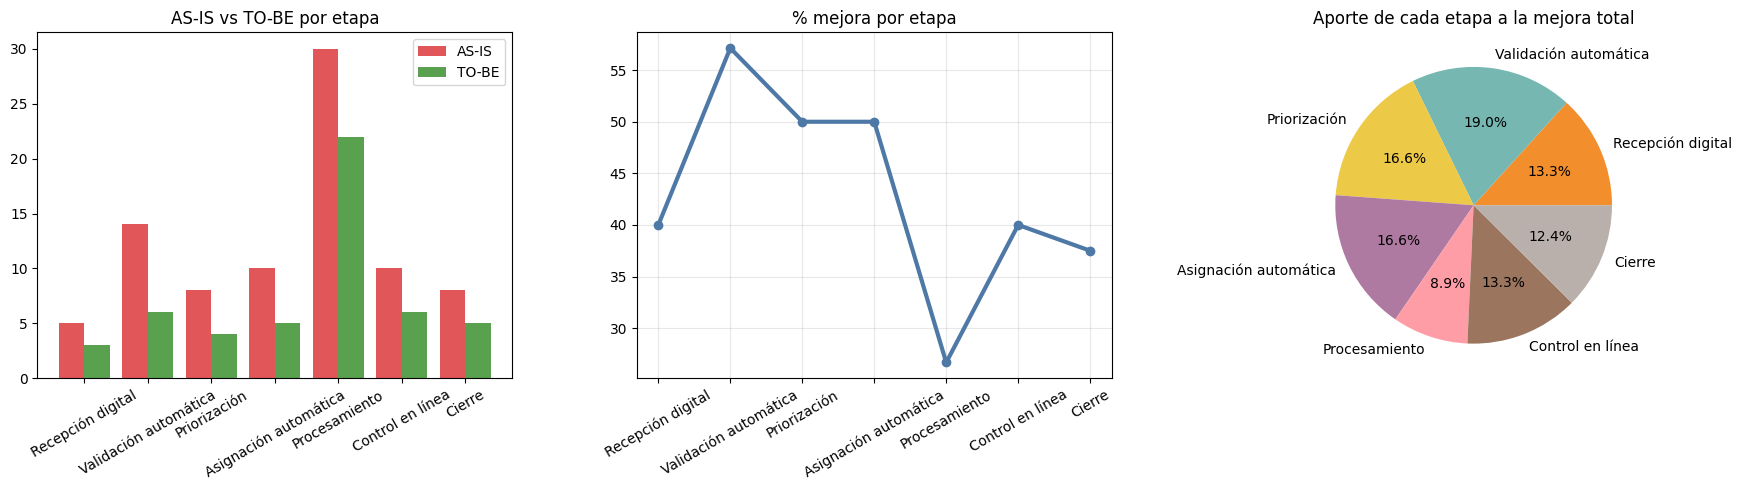

In [17]:
etapas_tobe = pd.DataFrame({
    "etapa": ["Recepción digital", "Validación automática", "Priorización", "Asignación automática", "Procesamiento", "Control en línea", "Cierre"],
    "tiempo_asis": [5, 14, 8, 10, 30, 10, 8],
    "tiempo_tobe": [3, 6, 4, 5, 22, 6, 5]
})

etapas_tobe["mejora_pct"] = ((etapas_tobe["tiempo_asis"] - etapas_tobe["tiempo_tobe"]) / etapas_tobe["tiempo_asis"]) * 100

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(etapas_tobe))
ax[0].bar(x - 0.2, etapas_tobe["tiempo_asis"], width=0.4, color="#e15759", label="AS-IS")
ax[0].bar(x + 0.2, etapas_tobe["tiempo_tobe"], width=0.4, color="#59a14f", label="TO-BE")
ax[0].set_xticks(x)
ax[0].set_xticklabels(etapas_tobe["etapa"], rotation=30)
ax[0].set_title("AS-IS vs TO-BE por etapa")
ax[0].legend()

ax[1].plot(etapas_tobe["etapa"], etapas_tobe["mejora_pct"],
           marker='o', linewidth=3, color="#4e79a7")
ax[1].set_title("% mejora por etapa")
ax[1].tick_params(axis='x', rotation=30)
ax[1].grid(alpha=0.3)

ax[2].pie(etapas_tobe["mejora_pct"], labels=etapas_tobe["etapa"],
          autopct='%1.1f%%',
          colors=["#f28e2b","#76b7b2","#edc948","#af7aa1","#ff9da7","#9c755f","#bab0ab"])
ax[2].set_title("Aporte de cada etapa a la mejora total")

plt.tight_layout()
plt.show()